# Logstash traffic overview

Dashboard exported from example-mcp-dashbuilder


In [7]:
from elasticsearch import Elasticsearch
import pandas as pd
import matplotlib.pyplot as plt

# Update with your Elasticsearch credentials
es = Elasticsearch(
    "http://localhost:9200",
    # api_key="your-api-key-here"
    basic_auth=("elastic", "changeme")
)


## Total requests

Chart type: **metric**


In [8]:
result = es.esql.query(
    query="""
    FROM logstash-*
    | STATS total_requests = COUNT(*)
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
print(f"Total requests: {df.iloc[0]['total_requests']}")
plt.tight_layout()
plt.show()


Total requests: 1000334


/var/folders/cn/rd9ggb657gxf0chyt7c1w_600000gn/T/ipykernel_66936/1368441596.py:1: ElasticsearchWarning: No limit defined, adding default limit of [1000]
  result = es.esql.query(


<Figure size 640x480 with 0 Axes>

## Top 5 geographic sources

Chart type: **bar**


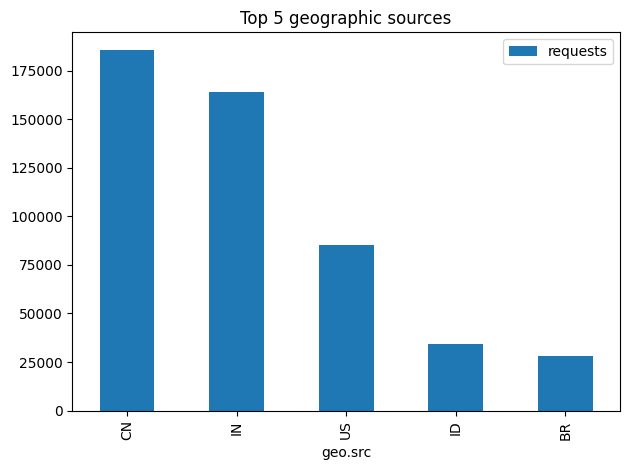

In [9]:
result = es.esql.query(
    query="""
    FROM logstash-*
    | WHERE geo.src IS NOT NULL
    | STATS requests = COUNT(*) BY geo.src
    | SORT requests DESC
    | LIMIT 5
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
df.plot.bar(x="geo.src", y=["requests"], title="Top 5 geographic sources")
plt.tight_layout()
plt.show()
